# Unemployment Analysis with Python

## Introduction

This project analyzes unemployment data in India to understand regional and time-based unemployment trends. It also studies the impact of COVID-19 on unemployment rates.


In [29]:
# Import pandas for data analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for creating graphs
import matplotlib.pyplot as plt

# Import seaborn for data visualization
import seaborn as sns

 Load the Dataset

In [30]:
# Load the unemployment dataset
df = pd.read_csv("Unemployment in India.csv")

# Display the first five rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


Check Dataset Shape

In [31]:
# Check the number of rows and columns
df.shape

(768, 7)

Check Data Types

In [32]:
# Check the data type of each column
df.dtypes

Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

Check Missing Values

In [33]:
# Check the number of missing values in each column
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Descriptive Statistics

In [34]:
# Display basic statistical information about numerical columns
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


Clean the Dataset

In [35]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check the column names after cleaning
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Check the Cleaned Dataset

In [36]:
# Display the first five rows of the cleaned dataset
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


Convert the Date Column

In [37]:
# Convert the Date column from text format to date format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Display the first five dates
df['Date'].head()

0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]

Check the Unique Regions

In [38]:
# Display all unique regions in the dataset
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', nan, 'Chandigarh'],
      dtype=object)

Check Unique Areas

In [39]:
# Display the unique areas in the dataset
df['Area'].unique()

array(['Rural', nan, 'Urban'], dtype=object)

Region-wise Average Unemployment

In [40]:
# Calculate the average unemployment rate for each region
region_avg_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

# Display the average unemployment rate of each region
region_avg_unemployment

Region
Andhra Pradesh       7.477143
Assam                6.428077
Bihar               18.918214
Chandigarh          15.991667
Chhattisgarh         9.240357
Delhi               16.495357
Goa                  9.274167
Gujarat              6.663929
Haryana             26.283214
Himachal Pradesh    18.540357
Jammu & Kashmir     16.188571
Jharkhand           20.585000
Karnataka            6.676071
Kerala              10.123929
Madhya Pradesh       7.406429
Maharashtra          7.557500
Meghalaya            4.798889
Odisha               5.657857
Puducherry          10.215000
Punjab              12.031071
Rajasthan           14.058214
Sikkim               7.249412
Tamil Nadu           9.284286
Telangana            7.737857
Tripura             28.350357
Uttar Pradesh       12.551429
Uttarakhand          6.582963
West Bengal          8.124643
Name: Estimated Unemployment Rate (%), dtype: float64

Visualize Region-wise Average Unemployment

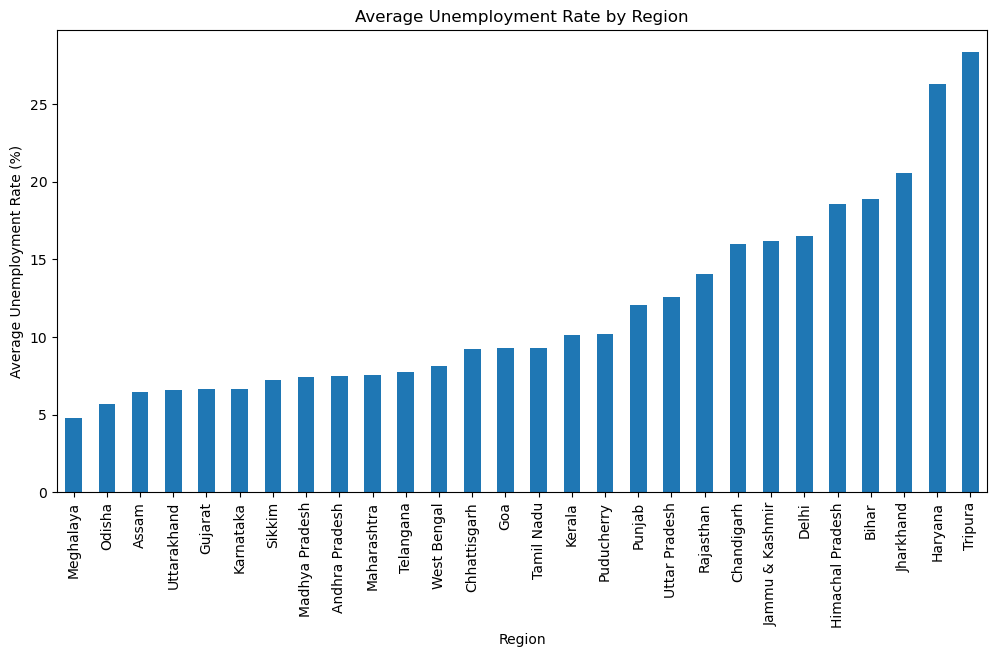

In [41]:
# Create a bar chart for the average unemployment rate of each region
plt.figure(figsize=(12, 6))

# Plot the average unemployment rate
region_avg_unemployment.sort_values().plot(kind='bar')

# Add title and labels
plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')

# Rotate region names for better readability
plt.xticks(rotation=90)

# Display the chart
plt.show()

Month-wise Unemployment Trend

In [42]:
# Extract the month from the Date column
df['Month'] = df['Date'].dt.month

# Calculate the average unemployment rate for each month
monthly_unemployment = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

# Display the month-wise average unemployment rate
monthly_unemployment

Month
1.0      9.950755
2.0      9.964717
3.0     10.700577
4.0     23.641569
5.0     16.646190
6.0     10.553462
7.0      9.033889
8.0      9.637925
9.0      9.051731
10.0     9.900909
11.0     9.868364
12.0     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64

Month-wise Unemployment Line Chart

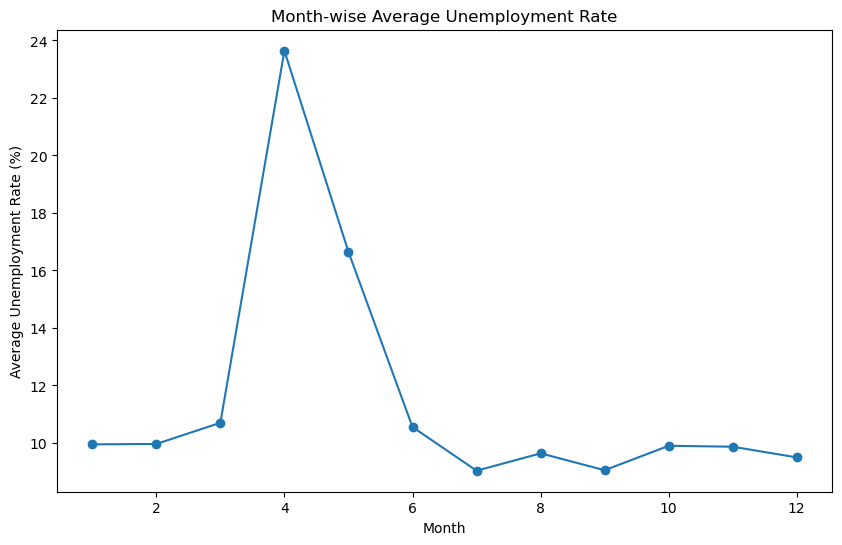

In [43]:
# Create a line chart for the month-wise unemployment rate
plt.figure(figsize=(10, 6))

# Plot the monthly unemployment rate
plt.plot(monthly_unemployment.index, monthly_unemployment.values, marker='o')

# Add title and labels
plt.title('Month-wise Average Unemployment Rate')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

# Display the chart
plt.show()

Time-Series Analysis for 3 Regions

In [44]:
# Select three regions for time-series analysis
selected_regions = ['Andhra Pradesh', 'Kerala', 'Tamil Nadu']

# Filter the dataset for the selected regions
three_regions = df[df['Region'].isin(selected_regions)]

# Display the selected data
three_regions[['Region', 'Date', 'Estimated Unemployment Rate (%)']].head()

,Region,Date,Estimated Unemployment Rate (%)
0,Andhra Pradesh,2019-05-31,3.65
1,Andhra Pradesh,2019-06-30,3.05
2,Andhra Pradesh,2019-07-31,3.75
3,Andhra Pradesh,2019-08-31,3.32
4,Andhra Pradesh,2019-09-30,5.17


Create the 3-Region Time-Series Chart

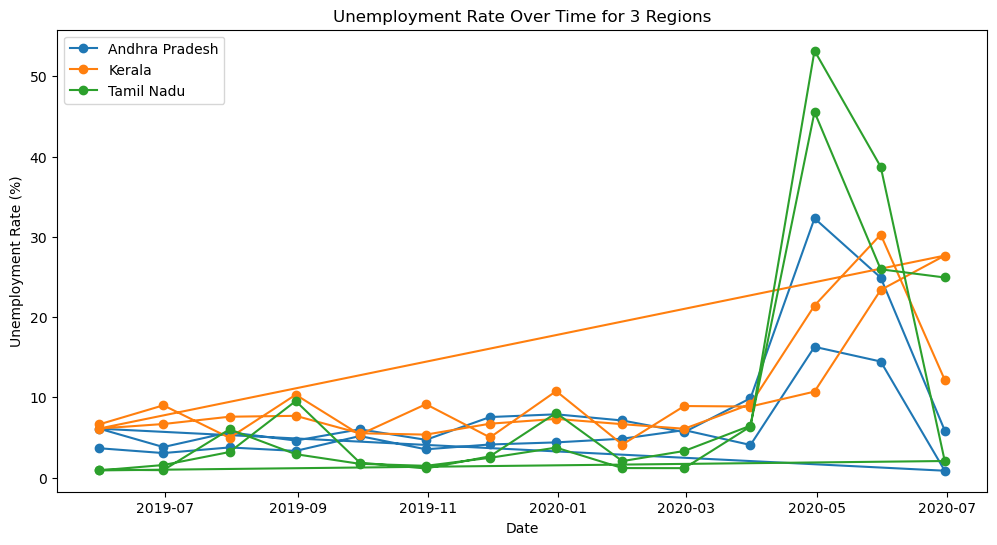

In [45]:
# Create a figure for the time-series chart
plt.figure(figsize=(12, 6))

# Plot unemployment rate for each selected region
for region in selected_regions:
    region_data = three_regions[three_regions['Region'] == region]
    plt.plot(
        region_data['Date'],
        region_data['Estimated Unemployment Rate (%)'],
        marker='o',
        label=region
    )

# Add title and labels
plt.title('Unemployment Rate Over Time for 3 Regions')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

# Show the region names
plt.legend()

# Display the chart
plt.show()

Find the Top 10 Regions with Highest Average Unemployment

In [46]:
# Sort regions by average unemployment rate in descending order
top_10_regions = region_avg_unemployment.sort_values(ascending=False).head(10)

# Display the top 10 regions
top_10_regions

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

Top 10 Regions Bar Chart

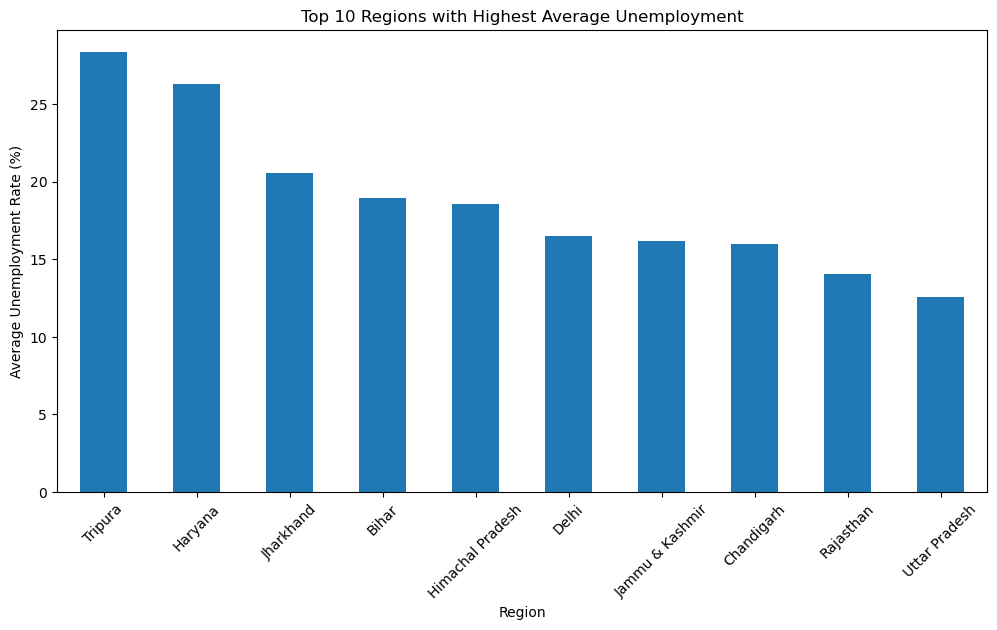

In [47]:
# Create a bar chart for the top 10 regions
plt.figure(figsize=(12, 6))

# Plot the top 10 regions
top_10_regions.plot(kind='bar')

# Add title and labels
plt.title('Top 10 Regions with Highest Average Unemployment')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')

# Rotate region names for better readability
plt.xticks(rotation=45)

# Display the chart
plt.show()

Correlation Analysis

In [48]:
# Select the numerical columns for correlation analysis
correlation = df.select_dtypes(include='number').corr()

# Display the correlation values
correlation

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Month
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558,-0.122938
Estimated Employed,-0.222876,1.000000,0.011300,0.011285
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000,0.087257
Month,-0.122938,0.011285,0.087257,1.000000


Create the Correlation Heatmap

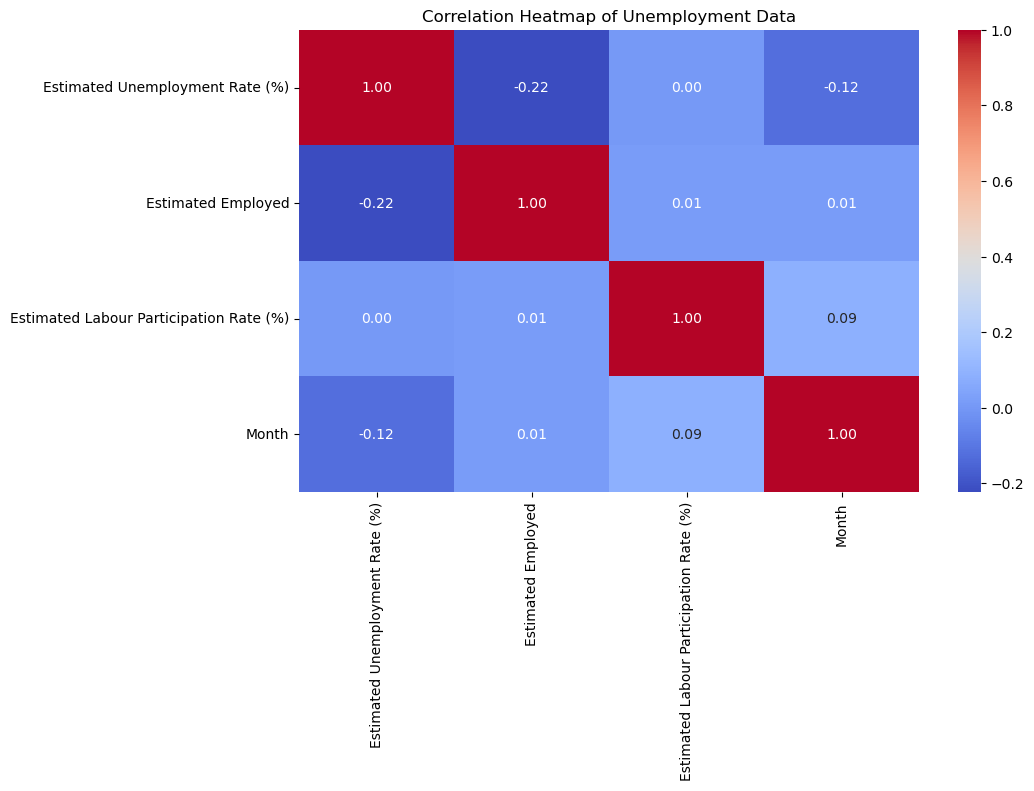

In [49]:
# Create a figure for the correlation heatmap
plt.figure(figsize=(10, 6))

# Display the correlation matrix as a heatmap
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

# Add title
plt.title('Correlation Heatmap of Unemployment Data')

# Display the heatmap
plt.show()

Pre-COVID vs Post-COVID Analysis

In [50]:
# Define the COVID period
covid_start = pd.Timestamp('2020-03-01')

# Create a new column to classify the data
df['COVID Period'] = df['Date'].apply(
    lambda x: 'Pre-COVID' if x < covid_start else 'Post-COVID'
)

# Display the number of records in each period
df['COVID Period'].value_counts()

COVID Period
Pre-COVID     536
Post-COVID    232
Name: count, dtype: int64

Calculate Average Unemployment Before and During COVID

In [51]:
# Calculate the average unemployment rate for each COVID period
covid_comparison = df.groupby('COVID Period')['Estimated Unemployment Rate (%)'].mean()

# Display the average unemployment rate
covid_comparison

COVID Period
Post-COVID    17.774363
Pre-COVID      9.509534
Name: Estimated Unemployment Rate (%), dtype: float64

COVID Comparison Bar Chart

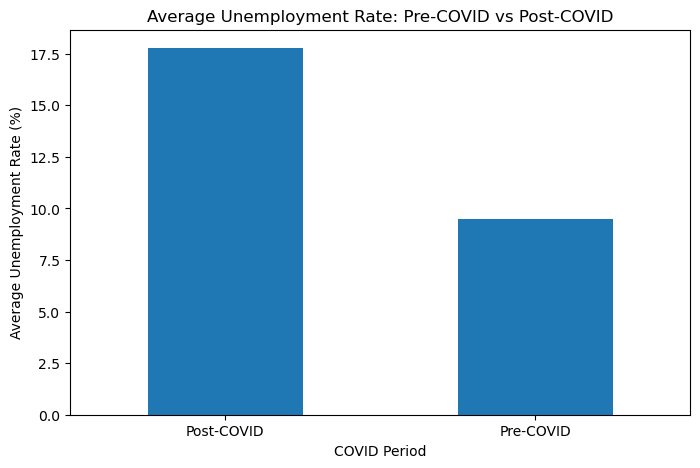

In [52]:
# Create a bar chart to compare unemployment before and during COVID-19
plt.figure(figsize=(8, 5))

# Plot the average unemployment rate
covid_comparison.plot(kind='bar')

# Add title and labels
plt.title('Average Unemployment Rate: Pre-COVID vs Post-COVID')
plt.xlabel('COVID Period')
plt.ylabel('Average Unemployment Rate (%)')

# Display the chart
plt.xticks(rotation=0)
plt.show()

## Observations

- The unemployment rate varies across different regions of India.
- Some regions have a higher average unemployment rate than others.
- The month-wise analysis shows that unemployment changes over time.
- The time-series analysis shows different unemployment trends for different regions.
- The Top 10 analysis identifies the regions with the highest average unemployment rates.
- The correlation analysis shows the relationship between unemployment, employment, and labour participation.
- The Pre-COVID vs Post-COVID comparison helps us understand the impact of COVID-19 on unemployment.

## Conclusion

The analysis of unemployment data in India helped identify regional and time-based unemployment trends. The study also showed the differences in unemployment rates across regions and the changes during the COVID-19 period. Data visualization and statistical analysis made these trends easier to understand.